[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/storopoli/ciencia-de-dados/main?filepath=notebooks%2FAula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)
<br>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/storopoli/ciencia-de-dados/blob/main/notebooks/Aula_19_Redes_Neurais_Convolucionais_com_PyTorch.ipynb)

# Redes Neurais Convolucionais com PyTorch

#### DATASET [Fashion-MNIST](https://en-wikipedia-org.translate.goog/wiki/Fashion-MNIST?_x_tr_sl=en&_x_tr_tl=pt&_x_tr_hl=pt&_x_tr_pto=tc)

Apos o treinamento, vou comparar os resultados do dataset Fashion_MNIST com os resultados obtidos usando o dataset MNIST

In [15]:
import torch

A variavel device vai mapear o hardware disponivel, selecionando a placa de video cuda ou a cpu.

In [16]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de treinamento/avaliação selecionado: {device}')

Dispositivo de treinamento/avaliação selecionado: cpu


Apos a seleção, vou usar o método .to(device) para mover o modelo e os tensores para GPU. Isso garante velocidade e poder computacional durante o loop de treinamento e avaliação.

O pacote `torchvision` do `PyTorch` já tem integrado o dataset FashionMNIST:

In [17]:
import torchvision
from torchvision import transforms

# FashionMNIST dataset
root_path = '/home/ghca/Downloads'

# Pequena transformação para tensores e normalizando o tamanho
trans = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

# Train/Test Datasets
train_dataset = torchvision.datasets.FashionMNIST(root=root_path, train=True, transform=trans, download=True)
test_dataset = torchvision.datasets.FashionMNIST(root=root_path, train=False, transform=trans)

In [18]:
train_dataset

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: /home/ghca/Downloads
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

In [19]:
test_dataset

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: /home/ghca/Downloads
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.1307,), std=(0.3081,))
           )

Vou implementar [`torch.utils.data.DataLoader()`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) para controlar como que os dados são inseridos no modelo.

O dataset Fashion-MNIST de treino tem 60.000 imagens no total, vou fazer uma separação aleatoria de 50.000 para treino e 10.000 para validação.

Apos a separação vou criar os DataLoaders.

In [20]:
from torch.utils.data import DataLoader, random_split

batch_size = 32

tamanho_treino = 50000
tamanho_validacao = 10000
train_data, val_data = random_split(train_dataset, [tamanho_treino, tamanho_validacao])

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

classes_fashion = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Construindo a rede neural convolucional no PyTorch

Temos que criar uma Rede Neural a partir de uma classe [`nn.Module()`](https://pytorch.org/docs/stable/generated/torch.nn.Module.html?highlight=module#torch.nn.Module) e criar um construtor com o método `__init__()` e implementar todas as layers e propagações desejadas com o método `forward()`.

In [21]:
import torch.nn as nn

In [22]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        self.fc1 = nn.Sequential(
            nn.Linear(7 * 7 * 64, 1000),
            nn.ReLU())
        self.fc2 = nn.Linear(1000, 10)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = out.reshape(out.size(0), -1)
        out = self.fc1(out)
        out = self.fc2(out)
        return out

# Instancia o Model() e move para o  selecionado
model = ConvNet().to(device)

print(model)

ConvNet(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Sequential(
    (0): Linear(in_features=3136, out_features=1000, bias=True)
    (1): ReLU()
  )
  (fc2): Linear(in_features=1000, out_features=10, bias=True)
)


Quantidade de parametros

In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

count_parameters(model)

3199106

## Treinando a rede neural no PyTorch

Uma vez especificado e instanciado o modelo, podemos manipulá-lo de maneira dinâmica.
Escolhemos a função custo (`loss_fn`) como `nn.CrossEntropyLoss()` e também a taxa de aprendizagem $\eta$ em `1e-6` e a quantidade de épocas a serem treinadas (`epochs`):

```python
model = Sua_rede_neural()
loss_fn = nn.CrossEntropyLoss()
learning_rate = 1e-6
epochs = 100

# Instânciar o Otimizador Adam
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

# For-loop de treino
for epoch in range(epochs): # para cada época
    for (images, labels) in train_loader: # para cada batch
        # Gera a propagação (feed forward)
        outputs = model(images)
        
        # Calcula a função-custo
        loss = loss_fn(outputs, labels)
        
        # Retro-propagação (Backprop) e a otimização com Adam
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

In [24]:
from torch.optim import Adam

# Hiperparâmetros
loss_fn = nn.CrossEntropyLoss()
learning_rate = 0.001
epochs = 6

# Instânciar o Otimizador Adam
optimizer = Adam(model.parameters(), lr=learning_rate)

In [25]:
# Treinar modelo
total_step = len(train_loader)

# Guarda o historico em listas, um valor pra cada época
loss_por_epoca = []
acc_por_epoca = []
val_loss_list = []
val_acc_list = []

# Variáveis para auxiliar salvar o melhor modelo
melhor_acuracia_val = 0.0
caminho_arquivo = 'melhor_modelo_fashion_mnist.pth'

for epoch in range(epochs):

    # Fase de Treinamento
    model.train() # Aciona os mecanismos internos para o treinamento

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for i, (images, labels) in enumerate(train_loader):
        # Envia para a GPU
        images = images.to(device)
        labels = labels.to(device)

        # Feed forward e cálculo do erro
        outputs = model(images)
        loss = loss_fn(outputs, labels)

        # Acumula o custo
        train_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Acumula a acuracia
        train_total += labels.size(0)
        _, predicted = torch.max(outputs.data, 1)
        train_correct += (predicted == labels).sum().item()

        if (i + 1) % 100 == 0:
            print(f"Época [{epoch+1}/{epochs}], Step [{i+1}/{total_step}], Custo Atual: {round(loss.item(), 3)}")

    # Calculo da media do treino da epoca
    epoca_loss = train_loss / len(train_loader)
    epoca_acc = train_correct / train_total
    loss_por_epoca.append(epoca_loss)
    acc_por_epoca.append(epoca_acc)


    # Fase de Validação no final de cada época
    model.eval() # desliga o treinamento para realização dos teste

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    # Desliga o motor de aprendizado para economizar memória de GPU
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = loss_fn(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    # Médias da Validação
    val_loss_media = val_loss / len(val_loader)
    val_acc_media = val_correct / val_total

    val_loss_list.append(val_loss_media)
    val_acc_list.append(val_acc_media)

    # Salvar o melhor desempenho
    if val_acc_media > melhor_acuracia_val:
        melhor_acuracia_val = val_acc_media
        torch.save(model.state_dict(), caminho_arquivo)
        print(f"Melhor desempenho! Modelo salvo com acurácia: {round(val_acc_media*100, 2)}%")

    print(f"Época {epoch+1} | Custo Val: {round(val_loss_media, 3)} | Acc Val: {round(val_acc_media * 100, 3)}%\n")

Época [1/6], Step [100/1563], Custo Atual: 0.61
Época [1/6], Step [200/1563], Custo Atual: 0.457
Época [1/6], Step [300/1563], Custo Atual: 0.218
Época [1/6], Step [400/1563], Custo Atual: 0.266
Época [1/6], Step [500/1563], Custo Atual: 0.362
Época [1/6], Step [600/1563], Custo Atual: 0.626
Época [1/6], Step [700/1563], Custo Atual: 0.319
Época [1/6], Step [800/1563], Custo Atual: 0.337
Época [1/6], Step [900/1563], Custo Atual: 0.159
Época [1/6], Step [1000/1563], Custo Atual: 0.375
Época [1/6], Step [1100/1563], Custo Atual: 0.185
Época [1/6], Step [1200/1563], Custo Atual: 0.238
Época [1/6], Step [1300/1563], Custo Atual: 0.145
Época [1/6], Step [1400/1563], Custo Atual: 0.518
Época [1/6], Step [1500/1563], Custo Atual: 0.132
Melhor desempenho! Modelo salvo com acurácia: 89.33%
Época 1 | Custo Val: 0.278 | Acc Val: 89.33%

Época [2/6], Step [100/1563], Custo Atual: 0.295
Época [2/6], Step [200/1563], Custo Atual: 0.22
Época [2/6], Step [300/1563], Custo Atual: 0.687
Época [2/6], St

### Carregando o Melhor Modelo

Para validar que o salvamento, vamos carregar o modelo salvo em uma nova instancia.

Vou criar um modelo sem treinamento e inserir os pesos salvos nele.

In [26]:
caminho_arquivo = 'melhor_modelo_fashion_mnist.pth'
melhor_modelo_carregado = ConvNet().to(device)
pesos_salvos = torch.load(caminho_arquivo)
melhor_modelo_carregado.load_state_dict(pesos_salvos)
melhor_modelo_carregado.eval()

print("Pesos carregados com sucesso na nova instância!")

Pesos carregados com sucesso na nova instância!


### Análise Gráfica

Usei o Matplotlib para analisar o comportamento das curvas de treino e validação, para detectarmos um possivel Overfitting.

Se a curva de perda de treinamento cair enquanto a curva de validação sobe, temos um sinal de Overfitting. Isso indicaria que o modelo parou de aprender e começou a decorar.

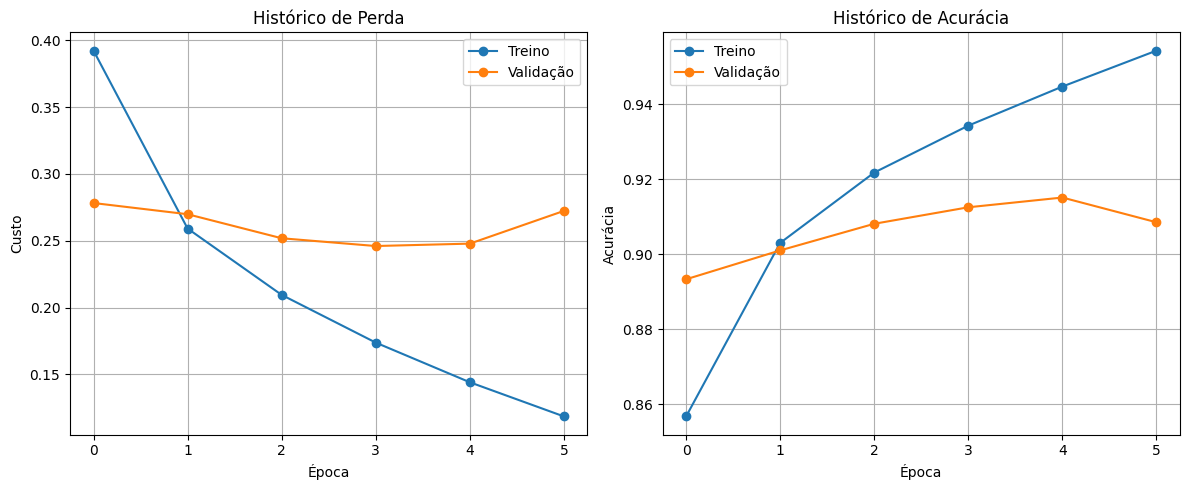

In [27]:
import matplotlib.pyplot as plt

# Perda
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_por_epoca, label='Treino', marker='o')
plt.plot(val_loss_list, label='Validação', marker='o')
plt.title('Histórico de Perda')
plt.xlabel('Época')
plt.ylabel('Custo')
plt.legend()
plt.grid(True)

# Acurácia
plt.subplot(1, 2, 2)
plt.plot(acc_por_epoca, label='Treino', marker='o')
plt.plot(val_acc_list, label='Validação', marker='o')
plt.title('Histórico de Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Acurácia do Melhor Modelo

In [28]:
# Modo de avaliação
melhor_modelo_carregado.eval()

with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        # Move os dados para o dispositivo
        images = images.to(device)
        labels = labels.to(device)

        # Feed-forward com as imagens de teste
        outputs = model(images)

        # Gera as predições usando max()
        _, predicted = torch.max(outputs.data, 1)

        # Acumula total e corretas
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Acurácia do Modelo em 10k imagens de teste: {round((correct / total) * 100, 3)}")

Acurácia do Modelo em 10k imagens de teste: 90.63


### Análise de diferenças entre Fashion-MNIST e MNIST

O resultado da acurácia do Fashion-MNIST foi por volta de 9% menor comparado com o MNIST, porem mesmo assim o resultado final foi muito bom.

O modelo teve uma curva de validação menos acentuada, porem a rede foi capaz de aprender. Esse detalhe na validação, indica que imagens de roupas tem texturas, dobras e formatos mais complexos em compração com as imagens de numeros do MNIST.

Conclusão: O Fashion-MNIST é um dataset mais desafiador, com imagens mais complexas, porem mesmo assim, o a rede neural conseguiu ser flexivel o sufiente para aprender com os dois datasets.